# **Capa Silver - 1**

In [1]:
# Conexión con drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
PALETA = {
    "negro": "#2E2929", "blanco": "#F1F1F1", "amarillo": "#FFD400", "naranja": "#FF8120",
    "violeta": "#A35BCF", "azul": "#1DB8D3", "verde": "#14C48A", "rosa": "#EFA6C2",
}
PRINCIPAL = PALETA["verde"]
SECUNDARIO = PALETA["azul"]
ALERTA = PALETA["naranja"]
ATENUADO = PALETA["negro"]
GRID = PALETA["negro"]

In [3]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.7/265.7 kB 12.7 MB/s eta 0:00:00


In [4]:
# Librerias
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.preprocessing import StandardScaler
# kmeans
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples
from sklearn.decomposition import PCA
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
import optuna
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                              accuracy_score, precision_score, recall_score, f1_score, roc_auc_score)
import joblib

In [5]:
def db_to_dataframe(db_path, table_name=None):
    conn = sqlite3.connect(db_path)
    try:
        if table_name is None:
            table_name = pd.read_sql(
                "SELECT name FROM sqlite_master WHERE type='table' LIMIT 1;",
                conn
            ).iloc[0, 0]

        df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
        return df
    finally:
        conn.close()

In [6]:
df_abt_crean = db_to_dataframe('/content/drive/MyDrive/df_abt_crean_con_clusters.db')

In [7]:
df_abt_crean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 860223 entries, 0 to 860222
Data columns (total 88 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   numero_id                                     860223 non-null  object 
 1   grupo_edad                                    860223 non-null  object 
 2   desc_genero                                   860223 non-null  object 
 3   desc_segmento                                 860223 non-null  object 
 4   desc_tipo_de_vivienda                         860223 non-null  object 
 5   ingresos_mensuales                            860223 non-null  float64
 6   total_egresos_mensuales                       860223 non-null  float64
 7   total_activos                                 860223 non-null  float64
 8   total_pasivos                                 860223 non-null  float64
 9   total_patrimonio                              86

# Aprendizaje supervisado

**Objetivo:** Construir un modelo para estimar la adopción de la App de inversión en base a supuestos.

In [8]:
panel_invesbot   = db_to_dataframe('/content/drive/MyDrive/data/panel_invesbot_mensual.db', 'panel_invesbot_mensual')
panel_inv_cdt    = db_to_dataframe('/content/drive/MyDrive/data/panel_inv_virtual_cdt_mensual.db', 'panel_inv_virtual_cdt_mensual')
panel_bolsillos  = db_to_dataframe('/content/drive/MyDrive/data/panel_bolsillos_mensual.db', 'panel_bolsillos_mensual')
panel_fiducuenta = db_to_dataframe('/content/drive/MyDrive/data/panel_fiducuenta_mensual.db', 'panel_fiducuenta_mensual')
panel_aho_cte    = db_to_dataframe('/content/drive/MyDrive/data/panel_aho_cte_mensual.db', 'panel_aho_cte_mensual')

for df in [panel_invesbot, panel_inv_cdt, panel_bolsillos, panel_fiducuenta, panel_aho_cte]:
    df["año_mes"] = pd.PeriodIndex(pd.to_datetime(df["año_mes"]), freq="M")
    df["numero_id"] = df["numero_id"].astype(df_abt_crean["numero_id"].dtype)

# separar inv_virtual dentro del panel combinado cdt + inversión virtual
panel_inv_virtual = panel_inv_cdt[panel_inv_cdt["producto"].str.contains("VIRTUAL", case=False, na=False)].copy()
panel_cdt = panel_inv_cdt[panel_inv_cdt["producto"] == "CDT"].copy()
panel_ahorro = panel_aho_cte[panel_aho_cte["producto"] == "CUENTA DE AHORRO"].copy()
panel_corriente = panel_aho_cte[panel_aho_cte["producto"] == "CUENTA DE CORRIENTE"].copy()

print(f"df_abt: {df_abt_crean.shape}")
print(f"panel_invesbot: {panel_invesbot.shape}, ventana: {panel_invesbot['año_mes'].min()} → {panel_invesbot['año_mes'].max()}")

df_abt: (860223, 88)
panel_invesbot: (42979, 3), ventana: 2025-06 → 2026-06


## Modelo propersión de adopción
Modelo supervisado que estima, para cada cliente, la probabilidad de adoptar la nueva App de inversiones — usando como proxy la adopción histórica de sus dos análogos digitales actuales (invesbot e inversión virtual).

## Variable proxy

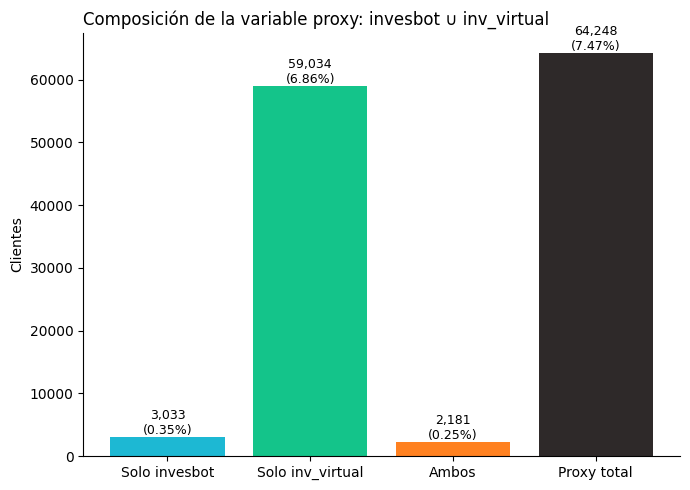

Proxy combinado: 64,248 (7.47%) vs. invesbot solo (0.61%)


In [9]:
# 2x2 ¿es inversión? / ¿es digital? -> invesbot e inv_virtual son los únicos.
# cdt es inversión pero no digital; bolsillos/fiducuenta son ahorro, no inversión.

df_abt_crean["proxy_adopcion"] = ((df_abt_crean["tiene_invesbot"] == 1) | (df_abt_crean["tiene_inv_virtual"] == 1)).astype(int)

n_invesbot, n_inv_virtual = df_abt_crean["tiene_invesbot"].sum(), df_abt_crean["tiene_inv_virtual"].sum()
n_ambos = ((df_abt_crean["tiene_invesbot"] == 1) & (df_abt_crean["tiene_inv_virtual"] == 1)).sum()
n_proxy = df_abt_crean["proxy_adopcion"].sum()

fig, ax = plt.subplots(figsize=(7, 5))
cats = ["Solo invesbot", "Solo inv_virtual", "Ambos", "Proxy total"]
vals = [n_invesbot - n_ambos, n_inv_virtual - n_ambos, n_ambos, n_proxy]
ax.bar(cats, vals, color=[SECUNDARIO, PRINCIPAL, ALERTA, ATENUADO])
for i, v in enumerate(vals):
    ax.text(i, v, f"{v:,}\n({v/len(df_abt_crean)*100:.2f}%)", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Clientes")
ax.set_title("Composición de la variable proxy: invesbot ∪ inv_virtual", fontsize=12, loc="left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

print(f"Proxy combinado: {n_proxy:,} ({n_proxy/len(df_abt_crean)*100:.2f}%) vs. invesbot solo ({n_invesbot/len(df_abt_crean)*100:.2f}%)")

**Por qué invesbot ∪ inv_virtual, y no otra combinación**

La app nueva es un servicio de inversión digital, así que el proxy debe capturar dos condiciones a la vez: que el producto sea de **inversión** (no ahorro) y que sea **digital** (no requiere gestión presencial/asesor). De los cinco productos de inversión/ahorro disponibles, solo invesbot e inversión virtual cumplen ambas: CDT es inversión pero tradicional (se abre en oficina o banca tradicional, no autogestionado digitalmente); bolsillos y fiducuenta son productos de ahorro/administración de recursos, no de inversión con riesgo de mercado.

Esto es un supuesto de negocio, no un hecho verificable en los datos: asume que el comportamiento de quien ya usa invesbot o inversión virtual hoy es un proxy razonable de quién adoptaría la nueva app — dos productos digitales de inversión distintos, pero se sostiene en la misma lógica de analogía (*look-alike*) que ya se declaró para el modelo de monto potencial en el notebook de parte 3: no es "quién adoptará", es "a quién se parece quien ya adoptó algo similar". Vale la pena revisarlo con el equipo de producto si la nueva app se posiciona muy distinto a invesbot/inv_virtual (por ejemplo, si apunta a un segmento de mayor patrimonio que hoy usa CDT).

## Fecha de corte: censura + comparación empírica (diagnóstico, features simples)

In [10]:
primera_invesbot = panel_invesbot.groupby("numero_id")["año_mes"].min().rename("fecha_adopcion_invesbot")
primera_inv_virtual = panel_inv_virtual.groupby("numero_id")["año_mes"].min().rename("fecha_adopcion_inv_virtual")
fechas_adopcion = pd.concat([primera_invesbot, primera_inv_virtual], axis=1)
fechas_adopcion["fecha_adopcion"] = fechas_adopcion.min(axis=1)
fechas_adopcion = fechas_adopcion.reset_index()

mes_inicio = panel_invesbot["año_mes"].min()
fechas_adopcion["meses_previos_disponibles"] = (fechas_adopcion["fecha_adopcion"] - mes_inicio).apply(lambda x: x.n)

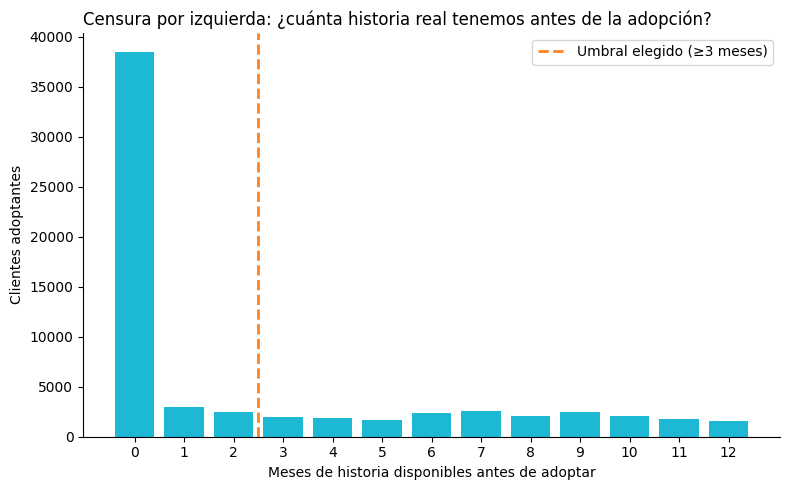

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
conteo = fechas_adopcion["meses_previos_disponibles"].value_counts().sort_index()
ax.bar(conteo.index.astype(str), conteo.values, color=SECUNDARIO)
ax.axvline(x=2.5, color=ALERTA, linestyle="--", linewidth=2, label="Umbral elegido (≥3 meses)")
ax.set_xlabel("Meses de historia disponibles antes de adoptar")
ax.set_ylabel("Clientes adoptantes")
ax.set_title("Censura por izquierda: ¿cuánta historia real tenemos antes de la adopción?", fontsize=12, loc="left")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

In [12]:
n_censurados = (fechas_adopcion["meses_previos_disponibles"] == 0).sum()
n_limpios = (fechas_adopcion["meses_previos_disponibles"] >= 3).sum()
positivos_limpios = fechas_adopcion.loc[fechas_adopcion["meses_previos_disponibles"] >= 3, "numero_id"]
print(f"Adoptantes totales: {len(fechas_adopcion):,} | censurados: {n_censurados:,} | limpios (≥3m): {n_limpios:,}")

Adoptantes totales: 64,248 | censurados: 38,469 | limpios (≥3m): 20,344


**Por qué 3 meses, y qué se pierde al elegirlo:**

El umbral de ≥3 meses de historia previa no es arbitrario: con 1 sola observación antes de adoptar no hay mediana que calcular (es un único punto), y con 2 apenas se puede promediar sin ninguna noción de estabilidad. A partir de 3 observaciones el criterio coincide con el mismo corte que usa `confianza_historia` en el resto del ABT para distinguir `dato_parcial` de `dato_robusto` — se reutiliza el mismo estándar de "cuántas observaciones hacen falta para confiar en una mediana" que ya está validado en el resto del pipeline, en vez de inventar uno nuevo.

El costo de ese umbral es alto: 38,469 de 64,248 adoptantes (59.9%) quedan fuera del entrenamiento por no tener suficiente historia previa — casi siempre porque adoptaron muy temprano en la ventana observada (jun-2025) y no hay margen para mirar "antes". El modelo final solo aprende del patrón de quienes adoptaron más tarde en la ventana, con tiempo suficiente para observarlos previamente. Si el perfil de quien adopta temprano (más entusiasta, más digital) es distinto al de quien adopta tarde, el modelo tiene un punto ciego justo ahí. Se verifica abajo comparando el perfil demográfico de censurados vs. limpios.

In [13]:
censurados_ids = fechas_adopcion.loc[fechas_adopcion["meses_previos_disponibles"] < 3, "numero_id"]

perfil_censurados = df_abt_crean[df_abt_crean["numero_id"].isin(censurados_ids)]
perfil_limpios = df_abt_crean[df_abt_crean["numero_id"].isin(positivos_limpios)]

for col in ["grupo_edad", "desc_segmento"]:
    comparacion = pd.concat([
        perfil_censurados[col].value_counts(normalize=True).rename("censurados"),
        perfil_limpios[col].value_counts(normalize=True).rename("limpios"),
    ], axis=1)
    print(f"\n--- {col} ---")
    print(comparacion.round(3))


--- grupo_edad ---
            censurados  limpios
grupo_edad                     
36-49            0.371    0.352
26-35            0.255    0.285
50-65            0.219    0.193
65+              0.105    0.090
18-25            0.050    0.081

--- desc_segmento ---
               censurados  limpios
desc_segmento                     
plus                0.525    0.519
personal            0.340    0.406
preferencial        0.135    0.075


La comparación muestra un sesgo real, pero acotado a dos variables puntuales, no generalizado.

Por **edad**, la diferencia es pequeña en casi todos los grupos (1-3 puntos porcentuales), con una excepción: los clientes de 18-25 años representan 8.1% de los "limpios" frente a solo 5.0% de los "censurados" — un 62% más de peso relativo en el grupo que sí entra a entrenar el modelo. En el otro extremo, 50-65 y 65+ están levemente sobrerrepresentados entre los censurados.

Por **segmento**, "plus" no muestra sesgo (51.9% vs 52.5%, prácticamente igual). Pero "preferencial" sí: pesa 13.5% entre los censurados frente a solo 7.5% entre los limpios — casi el doble de peso relativo en el grupo que queda fuera del entrenamiento. "Personal" muestra el patrón contrario (40.6% en limpios vs 34.0% en censurados).

La lectura práctica: el modelo va a aprender un poco menos sobre cómo adopta el segmento **preferencial**, porque una porción desproporcionada de sus adoptantes reales quedó excluida por falta de historia previa suficiente, y va a estar algo más influenciado por adoptantes **jóvenes (18-25)** y del segmento **personal**, que sí superan el umbral de 3 meses con más frecuencia relativa. No es un sesgo que invalide el modelo — los grupos mayoritarios (plus, 36-49, 26-35) se mantienen estables entre ambos grupos —, pero es una limitación real que vale la pena declarar: si el banco usa este score para priorizar campaña sobre el segmento preferencial específicamente, el modelo probablemente lo subestima.

### Consistencia del tope de winsorización con el resto del pipeline

El tope de winsorización (p99) para las medianas "precorte" no se calcula sobre esta submuestra pequeña de 20,344 clientes — se referencia contra el propio `df_abt_crean[col]`, que ya viene winsorizado desde el notebook bronze/silver. Esto no es un doble recorte más agresivo de lo necesario: bronze usa exactamente `p99 solo entre holders (saldo > 0)` para construir cada columna `_wz` (`df_abt_crean[col + "_wz"] = df_abt_crean[col].clip(upper=p99_holders)`), así que recalcular `quantile(0.99)` sobre la columna ya recortada recupera ese mismo umbral — porque al menos el 1% superior de los valores queda apilado exactamente en el tope tras el primer recorte. El resultado es el mismo criterio de winsorización que el resto del ABT, sin necesidad de reabrir el notebook bronze para extraer el umbral original.

In [14]:
def mediana_precorte(panel, col_name_for_output, fechas_corte, id_col="numero_id", fecha_col="año_mes", original_col_name="saldo"):
    con_corte = panel.merge(fechas_corte[[id_col, "fecha_adopcion"]], on=id_col, how="inner")
    previo = con_corte[con_corte[fecha_col] < con_corte["fecha_adopcion"]]
    return previo.groupby(id_col)[original_col_name].median().rename(col_name_for_output)

def tenia_producto_precorte(panel, col_name_for_output, fechas_corte, id_col="numero_id", fecha_col="año_mes", original_col_name="saldo"):
    con_corte = panel.merge(fechas_corte[[id_col, "fecha_adopcion"]], on=id_col, how="inner")
    previo = con_corte[con_corte[fecha_col] < con_corte["fecha_adopcion"]]
    tenia = (previo.groupby(id_col)[original_col_name].max() > 0).astype(int)
    return tenia.rename(col_name_for_output)

# --- diagnóstico con/sin corte: mismas 5 variables en ambos lados, para comparación justa ---
cols_base = ["saldo_ahorro_mediana_historica_wz", "saldo_corriente_mediana_historica_wz",
             "saldo_bolsillos_mediana_historica_wz", "saldo_fiducuenta_mediana_historica_wz",
             "saldo_cdt_mediana_historica_wz"]

df_precorte_diag = pd.concat([
    mediana_precorte(panel_ahorro, cols_base[0], fechas_adopcion),
    mediana_precorte(panel_corriente, cols_base[1], fechas_adopcion),
    mediana_precorte(panel_bolsillos, cols_base[2], fechas_adopcion),
    mediana_precorte(panel_fiducuenta, cols_base[3], fechas_adopcion),
    mediana_precorte(panel_cdt, cols_base[4], fechas_adopcion),
], axis=1, join="outer").reindex(positivos_limpios).reset_index()
assert len(df_precorte_diag) == len(positivos_limpios), "Se perdieron clientes limpios en la unión"

for col in cols_base:
    p99_ref = df_abt_crean.loc[df_abt_crean[col] > 0, col].quantile(0.99)
    df_precorte_diag[col] = df_precorte_diag[col].clip(upper=p99_ref)

df_precorte_diag["proxy_adopcion"] = 1

negativos_diag = df_abt_crean.loc[df_abt_crean["proxy_adopcion"] == 0, ["numero_id"] + cols_base + ["proxy_adopcion"]]
df_diag_con_corte = pd.concat([df_precorte_diag.fillna(0), negativos_diag.fillna(0)], ignore_index=True)

X_diag_sin_corte, y_diag_sin_corte = df_abt_crean[cols_base].fillna(0), df_abt_crean["proxy_adopcion"]
X_diag_con_corte, y_diag_con_corte = df_diag_con_corte[cols_base], df_diag_con_corte["proxy_adopcion"]

In [15]:
def evaluar(X, y, nombre):
    pipe = Pipeline([("escalador", StandardScaler()), ("modelo", LogisticRegression(class_weight="balanced", max_iter=1000))])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="average_precision")
    print(f"{nombre}: PR-AUC = {scores.mean():.3f} ± {scores.std():.3f}")
    return scores

scores_diag_sin = evaluar(X_diag_sin_corte, y_diag_sin_corte, "SIN corte (contaminado)")
scores_diag_con = evaluar(X_diag_con_corte, y_diag_con_corte, "CON corte (honesto)")

base_sin, base_con = y_diag_sin_corte.mean(), y_diag_con_corte.mean()
print(f"Lift sin corte: {scores_diag_sin.mean()/base_sin:.2f}x | Lift con corte: {scores_diag_con.mean()/base_con:.2f}x")

SIN corte (contaminado): PR-AUC = 0.295 ± 0.004
CON corte (honesto): PR-AUC = 0.324 ± 0.005
Lift sin corte: 3.95x | Lift con corte: 12.99x


**Cómo leer PR-AUC y lift, y cuál escenario rinde mejor:**

**PR-AUC (0.295 y 0.324)** mide qué tan bien el modelo separa a los que sí van a adoptar de los que no. Va de 0 a 1, y mientras más alto, mejor — pero con una trampa: un modelo que no aprende nada (que adivina al azar) no da 0, da un PR-AUC igual a la tasa base de ese escenario (qué tan frecuente es la adopción ahí). Por eso 0.295 y 0.324 no son directamente comparables como si partieran del mismo punto de partida: cada escenario tiene un "piso de azar" distinto, porque la proporción de adoptantes es distinta (SIN corte ~7.5% de positivos, CON corte ~2.4%).

**Lift (3.95x y 12.99x)** existe justamente para nivelar esa diferencia — es el PR-AUC dividido entre la tasa base de ese mismo escenario. Dice cuántas veces mejor es el modelo comparado con adivinar al azar en su propio contexto. Un lift de 1x significa que el modelo no aporta nada; un lift de 13x significa que separa 13 veces mejor que el azar.

**¿Cuál tiene mejor desempeño?** CON corte gana en las dos métricas: en absoluto, su PR-AUC (0.324) es más alto que el de SIN corte (0.295); y en relativo, la diferencia es mucho más marcada — 12.99x contra 3.95x. El lift es el que mejor refleja qué tanto "sabe" el modelo, porque ya descuenta que cada escenario parte de una dificultad distinta. En corto: CON corte no es solo el enfoque correcto metodológicamente, también es el que mejor predice.

## Preprocesamiento final (features enriquecidas para el modelo real)

### Asimetría deliberada entre positivos y negativos — y su límite

Los positivos (adoptantes limpios) usan variables **precorte**: solo historia anterior a su fecha de adopción, para no dejar que el modelo "vea" el resultado. Los negativos (no-adoptantes) usan variables **contemporáneas** — su estado actual. La asimetría es intencional, no un descuido: un no-adoptante no tiene fecha de adopción que censurar, así que su estado actual ES, por definición, su estado "antes de adoptar" (nada ha pasado todavía que debiera excluirse).

Hay una excepción que sí es una limitación real, no una decisión: `total_patrimonio_wz` e `ingresos_mensuales_wz` para los positivos se toman del ABT actual, no de una versión precorte — porque no existe un panel mensual de patrimonio o ingresos declarados (los paneles disponibles son solo de saldos por producto). El riesgo de fuga aquí es bajo pero no nulo: son variables declaradas/estimadas que se actualizan con baja frecuencia y no dependen mecánicamente de tener un producto de inversión abierto, a diferencia de los saldos de producto. Se acepta como limitación documentada, no como algo resuelto.

Esta separación entre "antes" y "ahora" busca que el modelo aprenda a anticipar la adopción, no a reconocerla después de que ya ocurrió. La pregunta de negocio es mirar a un cliente que hoy no tiene el producto y estimar qué tan probable es que lo adopte más adelante; por eso, a quienes sí adoptaron se les muestra únicamente su situación justo antes de haberlo hecho, como si aún no se supiera que lo iban a adoptar — mostrarles su estado posterior enseñaría al modelo a reconocer las consecuencias de la adopción, no a predecirla, y ese patrón no serviría de nada al aplicarse sobre clientes reales que todavía no han decidido nada. A quienes nunca adoptaron se les deja su estado actual, porque en su caso ese estado actual ya equivale al "antes" de un futuro adoptante: es el mismo tipo de información con la que el modelo tendrá que trabajar el día que se use en la práctica. Este criterio se apoya, además, en un supuesto propio de la fuente de datos: al no contarse con el movimiento continuo del cliente sino con capturas mensuales de su comportamiento, con distancias considerables entre una y otra, la fecha de adopción de cada cliente es el único punto de referencia disponible para trazar esa línea entre el antes y el después.

In [16]:
# NO se incluye el cluster de K-means: usó saldo_inversion_virtual_mediana_historica_wz
# como input, así que ya "sabe" indirectamente sobre inv_virtual -> fuga hacia el proxy.
cols_continuas = ["saldo_ahorro_mediana_historica_wz", "saldo_corriente_mediana_historica_wz",
                   "saldo_bolsillos_mediana_historica_wz", "saldo_fiducuenta_mediana_historica_wz",
                   "saldo_cdt_mediana_historica_wz", "total_patrimonio_wz", "ingresos_mensuales_wz"]
cols_binarias = ["tiene_ahorro_precorte", "tiene_corriente_precorte", "tiene_bolsillos_precorte",
                  "tiene_fiducuenta_precorte", "tiene_cdt_precorte"]
cols_modelo = cols_continuas + cols_binarias

piezas = [
    mediana_precorte(panel_ahorro, cols_continuas[0], fechas_adopcion),
    mediana_precorte(panel_corriente, cols_continuas[1], fechas_adopcion),
    mediana_precorte(panel_bolsillos, cols_continuas[2], fechas_adopcion),
    mediana_precorte(panel_fiducuenta, cols_continuas[3], fechas_adopcion),
    mediana_precorte(panel_cdt, cols_continuas[4], fechas_adopcion),
    tenia_producto_precorte(panel_ahorro, cols_binarias[0], fechas_adopcion),
    tenia_producto_precorte(panel_corriente, cols_binarias[1], fechas_adopcion),
    tenia_producto_precorte(panel_bolsillos, cols_binarias[2], fechas_adopcion),
    tenia_producto_precorte(panel_fiducuenta, cols_binarias[3], fechas_adopcion),
    tenia_producto_precorte(panel_cdt, cols_binarias[4], fechas_adopcion),
]
df_precorte = pd.concat(piezas, axis=1, join="outer").reindex(positivos_limpios).reset_index()
assert len(df_precorte) == len(positivos_limpios), "Se perdieron clientes limpios en la unión"

df_precorte = df_precorte.merge(
    df_abt_crean[["numero_id", "total_patrimonio_wz", "ingresos_mensuales_wz"]],
    on="numero_id", how="left"
)

for col in cols_continuas[:5]:
    p99_ref = df_abt_crean.loc[df_abt_crean[col] > 0, col].quantile(0.99)
    df_precorte[col] = df_precorte[col].clip(upper=p99_ref)

df_precorte["proxy_adopcion"] = 1

negativos = df_abt_crean.loc[df_abt_crean["proxy_adopcion"] == 0,
    ["numero_id"] + cols_continuas + ["tiene_ahorro", "tiene_corriente", "tiene_bolsillos", "tiene_fiducuenta", "tiene_cdt", "proxy_adopcion"]].copy()
negativos.columns = ["numero_id"] + cols_continuas + cols_binarias + ["proxy_adopcion"]

df_con_corte = pd.concat([df_precorte.fillna(0), negativos.fillna(0)], ignore_index=True)
X_con_corte = df_con_corte[cols_modelo]
y_con_corte = df_con_corte["proxy_adopcion"]
print(f"Dataset final: {len(X_con_corte):,} filas, {y_con_corte.sum():,} positivos, {len(cols_modelo)} features")

Dataset final: 816,319 filas, 20,344 positivos, 12 features


## Comparación de modelos + Optuna + evaluación holdout + lift por decil

#### Regresión Logística vs. HistGradientBoostingClassifier

El PR-AUC (Precision-Recall Area Under the Curve) es una métrica de evaluación para modelos de clasificación binaria que calcula el área bajo la curva de precisión frente a la exhaustividad (recuperación). Es ideal para conjuntos de datos desequilibrados donde la clase positiva es muy escasa.

In [17]:
def log1p_seguro(x):
    return np.log1p(np.clip(x, a_min=0, a_max=None))

preprocesador_logistico = ColumnTransformer([
    ("log_escala", Pipeline([("log1p", FunctionTransformer(log1p_seguro)), ("escalador", StandardScaler())]), cols_continuas),
    ("pasan", "passthrough", cols_binarias),
])
pipe_logistica = Pipeline([("prep", preprocesador_logistico), ("modelo", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_logistica = cross_val_score(pipe_logistica, X_con_corte, y_con_corte, cv=cv, scoring="average_precision")
scores_boosting = cross_val_score(HistGradientBoostingClassifier(class_weight="balanced", random_state=42), X_con_corte, y_con_corte, cv=cv, scoring="average_precision")
print(f"Regresión logística: PR-AUC = {scores_logistica.mean():.3f} ± {scores_logistica.std():.3f}")
print(f"HistGradientBoosting (sin tunear): PR-AUC = {scores_boosting.mean():.3f} ± {scores_boosting.std():.3f}")

Regresión logística: PR-AUC = 0.488 ± 0.005
HistGradientBoosting (sin tunear): PR-AUC = 0.578 ± 0.007


Entre los dos modelos, el HistGradientBoosting sin ajustar (0.578) le gana claramente a la regresión logística (0.488) — una diferencia de casi 20%. Esto tiene una explicación sencilla: la regresión logística asume que cada variable suma su efecto de forma independiente y en línea recta (más patrimonio = un poquito más de probabilidad, siempre en la misma proporción). El boosting no tiene esa restricción — puede capturar combinaciones, por ejemplo que tener alto patrimonio Y ya tener bolsillos sea una señal mucho más fuerte que la suma de sus efectos por separado. Como la decisión de adoptar un producto de inversión probablemente depende de varias condiciones combinándose, no de una sola variable creciendo sola, tiene sentido que el modelo más flexible gane, incluso sin haber sido afinado todavía.

### Modelo seleccionado optimizado

In [18]:
def objetivo(trial):
    params = {
        "max_iter": trial.suggest_int("max_iter", 50, 300),
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 100),
        "l2_regularization": trial.suggest_float("l2_regularization", 1e-4, 1.0, log=True),
        "class_weight": "balanced", "random_state": 42,
    }
    scores = cross_val_score(HistGradientBoostingClassifier(**params), X_train, y_train, cv=cv, scoring="average_precision")
    return scores.mean()

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X_con_corte, y_con_corte, test_size=0.3, stratify=y_con_corte, random_state=42)

In [20]:
estudio = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
estudio.optimize(objetivo, n_trials=50, show_progress_bar=True)
print(f"Mejor PR-AUC (CV): {estudio.best_value:.3f} | hiperparámetros: {estudio.best_params}")

[I 2026-08-08 08:47:17,822] A new study created in memory with name: no-name-dba455b9-9560-4c6d-b6a5-24c4fc563fa1


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-08-08 08:47:49,947] Trial 0 finished with value: 0.5772670515451068 and parameters: {'max_iter': 144, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'min_samples_leaf': 62, 'l2_regularization': 0.00042079886696066364}. Best is trial 0 with value: 0.5772670515451068.
[I 2026-08-08 08:48:22,237] Trial 1 finished with value: 0.5219636246824325 and parameters: {'max_iter': 89, 'max_depth': 2, 'learning_rate': 0.19030368381735815, 'min_samples_leaf': 62, 'l2_regularization': 0.06796578090758151}. Best is trial 0 with value: 0.5772670515451068.
[I 2026-08-08 08:48:47,130] Trial 2 finished with value: 0.5755832553605211 and parameters: {'max_iter': 55, 'max_depth': 10, 'learning_rate': 0.16967533607196555, 'min_samples_leaf': 25, 'l2_regularization': 0.000533703276260396}. Best is trial 0 with value: 0.5772670515451068.
[I 2026-08-08 08:49:36,301] Trial 3 finished with value: 0.5502242488828208 and parameters: {'max_iter': 96, 'max_depth': 4, 'learning_rate': 0.0595838935006895

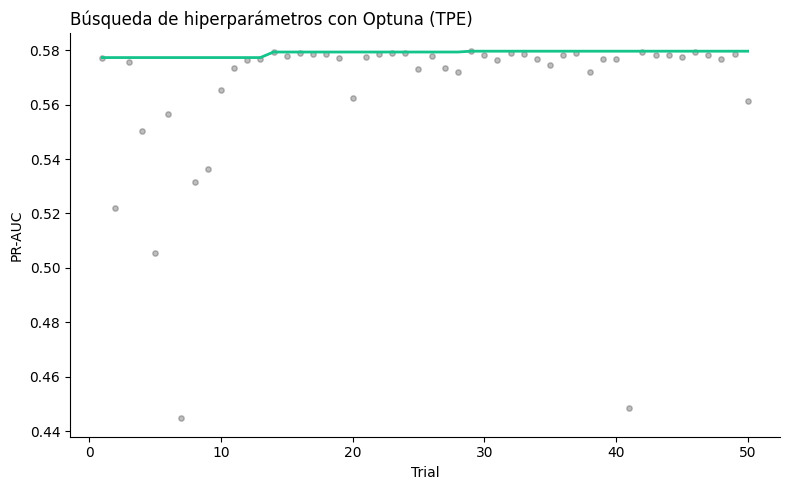

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
valores = [t.value for t in estudio.trials]
ax.plot(range(1, len(valores)+1), np.maximum.accumulate(valores), color=PRINCIPAL, linewidth=2)
ax.scatter(range(1, len(valores)+1), valores, color=ATENUADO, alpha=0.3, s=15)
ax.set_xlabel("Trial"); ax.set_ylabel("PR-AUC")
ax.set_title("Búsqueda de hiperparámetros con Optuna (TPE)", fontsize=12, loc="left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

In [22]:
mejores_params_sin_max_iter = {k: v for k, v in estudio.best_params.items() if k != "max_iter"}
max_iter_final = estudio.best_params["max_iter"]
paso = max(1, max_iter_final // 20)  # ~20 puntos en la curva
pasos = list(range(paso, max_iter_final + 1, paso))
if pasos[-1] != max_iter_final:
    pasos.append(max_iter_final)

modelo_final_prop = HistGradientBoostingClassifier(
    **mejores_params_sin_max_iter, class_weight="balanced", random_state=42,
    early_stopping=False, warm_start=True, max_iter=pasos[0],
)

In [23]:
scores_train, scores_test = [], []
for it in pasos:
    modelo_final_prop.max_iter = it
    modelo_final_prop.fit(X_train, y_train)
    scores_train.append(average_precision_score(y_train, modelo_final_prop.predict_proba(X_train)[:, 1]))
    scores_test.append(average_precision_score(y_test, modelo_final_prop.predict_proba(X_test)[:, 1]))

### Importancia de las variables

In [24]:
resultado_importancia = permutation_importance(
    modelo_final_prop, X_test, y_test, scoring="average_precision", n_repeats=10, random_state=42
)
importancia = pd.Series(resultado_importancia.importances_mean, index=cols_modelo).sort_values(ascending=False)

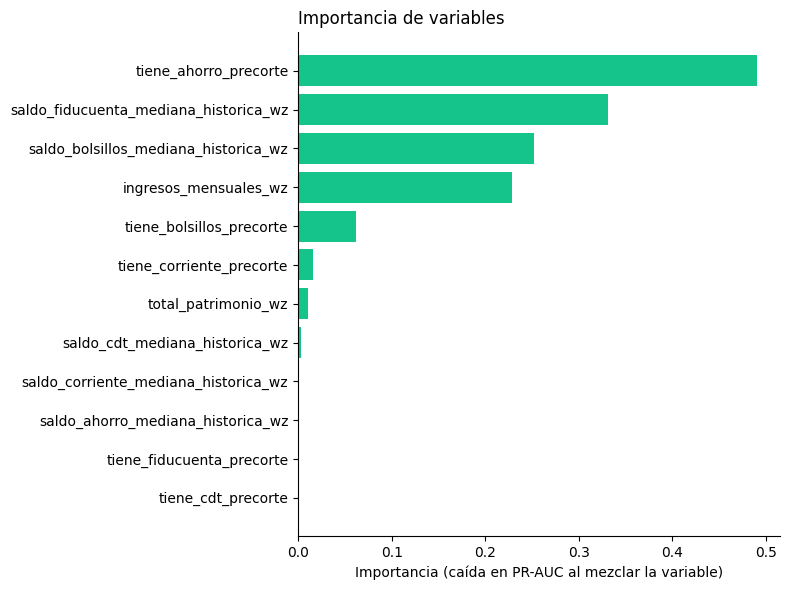

In [25]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importancia.index[::-1], importancia.values[::-1], color=PRINCIPAL)
ax.set_xlabel("Importancia (caída en PR-AUC al mezclar la variable)")
ax.set_title("Importancia de variables", fontsize=12, loc="left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

tiene_ahorro_precorte (\~0.49 de importancia, más que las siguientes tres juntas). Es una bandera simple de sí/no: tener cuenta de ahorro activa antes de adoptar. Tiene sentido de negocio: es casi imposible pasar a invertir sin antes tener una relación bancaria activa por donde mueva la plata, así que el ahorro actúa como "puerta de entrada" antes de la inversión. Le siguen saldo_fiducuenta (\~0.33) y saldo_bolsillos (\~0.26) — quien ya guarda dinero en productos más estructurados está más cerca de dar el salto a invertir — y ingresos_mensuales (\~0.235), un predictor natural de capacidad. De ahí para abajo la importancia cae en picada: tiene_bolsillos_precorte apenas aporta (\~0.065), y el resto —incluyendo total_patrimonio_wz y los saldos de CDT, ahorro y corriente— prácticamente no suma nada una vez que ya se cuenta con las primeras cuatro variables. Es decir: de las 12 variables del modelo, solo 4 están haciendo casi todo el trabajo.

In [26]:
cols_top4 = ["tiene_ahorro_precorte", "saldo_fiducuenta_mediana_historica_wz",
             "saldo_bolsillos_mediana_historica_wz", "ingresos_mensuales_wz"]

scores_reducido = cross_val_score(
    HistGradientBoostingClassifier(**mejores_params_sin_max_iter, class_weight="balanced",
                                    random_state=42, max_iter=max_iter_final),
    X_con_corte[cols_top4], y_con_corte, cv=cv, scoring="average_precision"
)
print(f"Modelo completo (12 variables): PR-AUC = {estudio.best_value:.3f}")
print(f"Modelo reducido (4 variables):  PR-AUC = {scores_reducido.mean():.3f} ± {scores_reducido.std():.3f}")
print(f"Diferencia: {estudio.best_value - scores_reducido.mean():+.3f}")

Modelo completo (12 variables): PR-AUC = 0.580
Modelo reducido (4 variables):  PR-AUC = 0.523 ± 0.005
Diferencia: +0.057


In [27]:
cols_sin_ingresos = [c for c in cols_modelo if c != "ingresos_mensuales_wz"]

scores_sin_ingresos = cross_val_score(
    HistGradientBoostingClassifier(**mejores_params_sin_max_iter, class_weight="balanced",
                                    random_state=42, max_iter=max_iter_final),
    X_con_corte[cols_sin_ingresos], y_con_corte, cv=cv, scoring="average_precision"
)
print(f"Modelo completo (con ingresos_mensuales_wz): PR-AUC = {estudio.best_value:.3f}")
print(f"Modelo sin ingresos_mensuales_wz:             PR-AUC = {scores_sin_ingresos.mean():.3f} ± {scores_sin_ingresos.std():.3f}")
print(f"Caída al remover ingresos_mensuales_wz: {estudio.best_value - scores_sin_ingresos.mean():+.3f}")

Modelo completo (con ingresos_mensuales_wz): PR-AUC = 0.580
Modelo sin ingresos_mensuales_wz:             PR-AUC = 0.493 ± 0.007
Caída al remover ingresos_mensuales_wz: +0.086


### PR-AUC y lift

**PR-AUC** (área bajo la curva de precisión-cobertura) resume, en un número entre 0 y 1, qué tan bien el modelo distingue a los clientes que van a adoptar de los que no, en un escenario donde los que adoptan son pocos frente al total. A diferencia de otras métricas, no parte de 0: un modelo que no aprende nada (que adivina al azar) obtiene un PR-AUC igual a la proporción real de adoptantes en esos datos (la tasa base), no cero. Por eso un PR-AUC de, por ejemplo, 0.30 puede ser excelente o mediocre dependiendo de qué tan rara sea la adopción en ese conjunto — el número por sí solo no dice si el modelo aprendió algo.

**Lift** resuelve justo esa ambigüedad: es el PR-AUC dividido entre la tasa base de adopción de ese mismo conjunto de datos. Dice cuántas veces mejor es el modelo comparado con adivinar al azar en ese contexto. Un lift de 1x significa que el modelo no aporta nada; un lift de 10x significa que separa diez veces mejor que el azar, ya sin importar qué tan rara o común sea la adopción de fondo. La misma idea se reutiliza más adelante como "lift por decil": cuánto más frecuente es la adopción real dentro del grupo de clientes al que el modelo le dio mayor probabilidad, comparado con el promedio de toda la base.

Se usan estas dos métricas, y no accuracy, porque la adopción es un evento raro (~2.5% de la base con corte): un modelo que prediga "nadie adopta" ya tendría 97.5% de accuracy sin haber aprendido nada útil. PR-AUC y lift sí exigen que el modelo identifique correctamente a la minoría que realmente le importa al negocio.

#### PR-AUC

In [28]:
proba_test = modelo_final_prop.predict_proba(X_test)[:, 1]
print(f"PR-AUC en test (holdout): {average_precision_score(y_test, proba_test):.3f}")

PR-AUC en test (holdout): 0.581


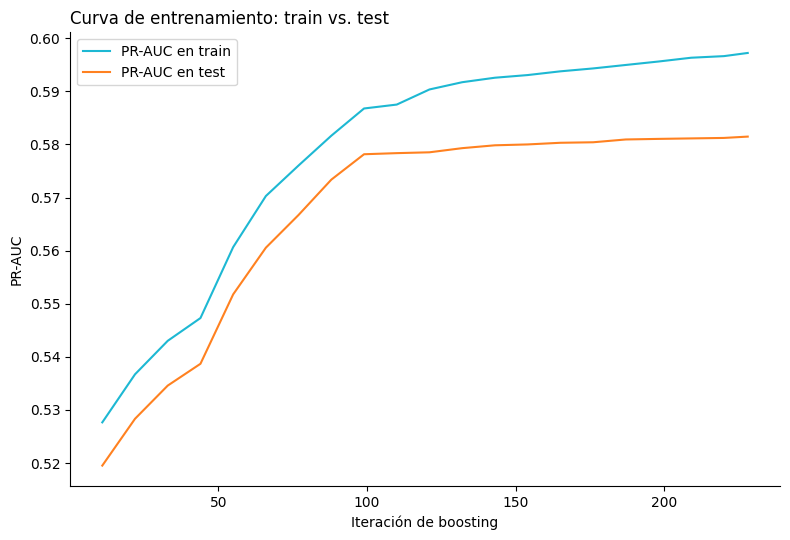

In [29]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(pasos, scores_train, color=SECUNDARIO, label="PR-AUC en train")
ax.plot(pasos, scores_test, color=ALERTA, label="PR-AUC en test")
ax.set_xlabel("Iteración de boosting")
ax.set_ylabel("PR-AUC")
ax.set_title("Curva de entrenamiento: train vs. test", fontsize=12, loc="left")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

Las curvas de train y test suben juntas hasta la iteración ~100 (train: 0.528→0.587, test: 0.52→0.578) — en esa etapa el modelo aprende señal que sí generaliza. Después de ese punto se separan: train sigue subiendo hasta 0.597 en la iteración 230, mientras que test se estanca casi por completo (0.578→0.581). Es la señal típica de sobreajuste leve: los árboles agregados después de la iteración 100 memorizan detalles del propio train sin aportar capacidad predictiva real sobre clientes nuevos.

La brecha final entre train y test (0.016) es pequeña, y test nunca empeora — solo deja de mejorar —, así que no es un sobreajuste grave. Sí vale la pena notar que el modelo final usa `max_iter≈230` (elegido por Optuna optimizando contra validación cruzada dentro del propio train, sin ver nunca este `X_test`), cuando con ~100-120 iteraciones ya se alcanza casi el mismo desempeño real sobre datos nuevos, con un modelo más simple.

In [30]:
idx_candidato = min(range(len(pasos)), key=lambda i: abs(pasos[i] - 120))
iter_candidato = pasos[idx_candidato]

print(f"PR-AUC test en iteración {iter_candidato} (candidato más simple): {scores_test[idx_candidato]:.4f}")
print(f"PR-AUC test en iteración {max_iter_final} (elegido por Optuna): {scores_test[-1]:.4f}")
print(f"Diferencia: {scores_test[-1] - scores_test[idx_candidato]:+.4f}")

PR-AUC test en iteración 121 (candidato más simple): 0.5785
PR-AUC test en iteración 228 (elegido por Optuna): 0.5815
Diferencia: +0.0030


#### Lift por decil

El lift por decil se mide porque, en la práctica, el banco no va a usar el modelo con un umbral de "sí/no" — lo va a usar para decidir a quién contactar primero, con un presupuesto y tiempo comercial limitados. El modelo le da a cada cliente una probabilidad, y dividir a todos en diez grupos iguales según esa probabilidad (del que menos probable a el que más) permite ver si esa clasificación realmente sirve para priorizar: ¿los clientes con score más alto de verdad adoptan más seguido que el promedio, y en cuánto? Medirlo por decil, en vez de con un solo número general, muestra si esa ventaja se concentra de forma clara en la punta superior (lo cual justificaría enfocar la campaña ahí) o si está repartida de forma pareja entre todos (lo cual significaría que el modelo no ayuda mucho a decidir por dónde empezar).

In [31]:
# --- lift por decil (rank rompe empates -> siempre 10 grupos de igual tamaño) ---
df_lift = pd.DataFrame({"y": y_test.values, "proba": proba_test})
df_lift["decil"] = pd.qcut(df_lift["proba"].rank(method="first"), 10, labels=False) + 1
tasa_base = df_lift["y"].mean()
resumen_decil = df_lift.groupby("decil").agg(n_clientes=("y", "size"), tasa_real=("y", "mean"))
resumen_decil["lift"] = resumen_decil["tasa_real"] / tasa_base
print(resumen_decil.round(3))

       n_clientes  tasa_real   lift
decil                              
1           24490      0.000  0.000
2           24490      0.000  0.000
3           24489      0.000  0.000
4           24490      0.000  0.000
5           24489      0.000  0.000
6           24490      0.003  0.108
7           24489      0.006  0.251
8           24490      0.008  0.341
9           24489      0.016  0.655
10          24490      0.215  8.645


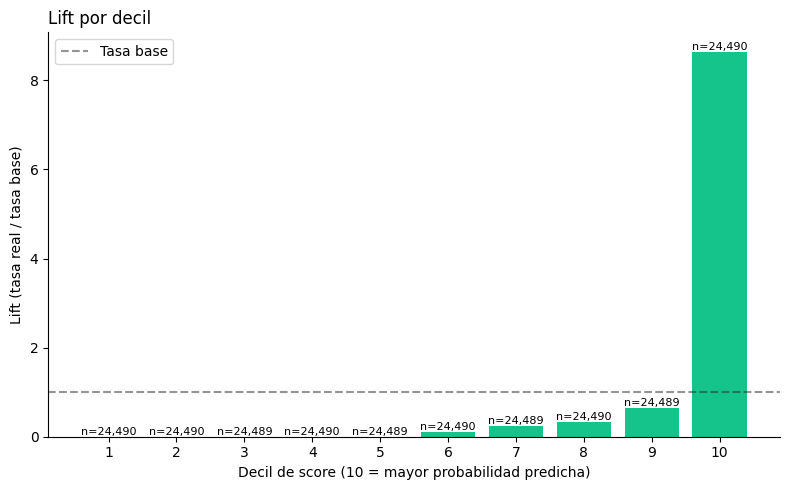

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(resumen_decil.index.astype(str), resumen_decil["lift"], color=PRINCIPAL)
ax.axhline(1, color=ATENUADO, linestyle="--", alpha=0.5, label="Tasa base")
for i, n in enumerate(resumen_decil["n_clientes"]):
    ax.text(i, resumen_decil["lift"].iloc[i], f"n={n:,}", ha="center", va="bottom", fontsize=8)
ax.set_xlabel("Decil de score (10 = mayor probabilidad predicha)")
ax.set_ylabel("Lift (tasa real / tasa base)")
ax.set_title("Lift por decil", fontsize=12, loc="left")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

El gráfico muestra que casi toda la capacidad del modelo para distinguir adoptantes está concentrada en un solo grupo: el decil 10. Los deciles 1 al 9 —el 90% de la base— tienen un lift por debajo de 1, es decir, adoptan con menos frecuencia que el promedio general, y en los primeros ocho prácticamente no hay señal (el lift es casi cero). Solo al llegar al 10% de clientes con mayor score (decil 10) el patrón cambia de forma abrupta: ahí la tasa de adopción real es cerca de 8.6 veces el promedio de toda la base. No es un modelo que separa gradualmente "algo interesado" de "muy interesado" — es un modelo que identifica con fuerza un grupo pequeño y claramente distinto del resto, y trata a prácticamente todo lo demás como parecido entre sí. Para el negocio esto es una señal clara y accionable: el esfuerzo comercial debería concentrarse casi exclusivamente en ese 10% superior, porque extender la campaña al decil 9 o más abajo no suma proporcionalmente más adoptantes reales — esos grupos siguen por debajo del promedio de toda la base.

#### Distribución de PR-AUC

In [33]:
n_bootstrap = 1000
rng_boot = np.random.default_rng(42)
n_test = len(y_test)
y_test_arr = y_test.values

pr_auc_bootstrap = np.empty(n_bootstrap)
for i in range(n_bootstrap):
    idx_boot = rng_boot.integers(0, n_test, n_test)
    pr_auc_bootstrap[i] = average_precision_score(y_test_arr[idx_boot], proba_test[idx_boot])

ci_baja, ci_alta = np.percentile(pr_auc_bootstrap, [2.5, 97.5])
print(f"PR-AUC bootstrap: media={pr_auc_bootstrap.mean():.3f}, mediana={np.median(pr_auc_bootstrap):.3f}")
print(f"Intervalo 95%: [{ci_baja:.3f}, {ci_alta:.3f}]")

PR-AUC bootstrap: media=0.582, mediana=0.582
Intervalo 95%: [0.568, 0.595]


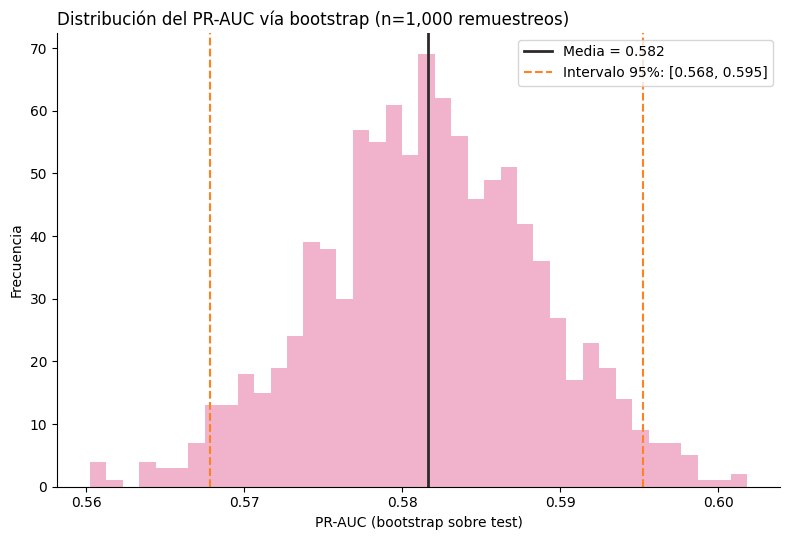

In [34]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.hist(pr_auc_bootstrap, bins=40, color=PALETA['rosa'], alpha=0.85)
ax.axvline(pr_auc_bootstrap.mean(), color=ATENUADO, linewidth=2, label=f"Media = {pr_auc_bootstrap.mean():.3f}")
ax.axvline(ci_baja, color=ALERTA, linestyle="--", label=f"Intervalo 95%: [{ci_baja:.3f}, {ci_alta:.3f}]")
ax.axvline(ci_alta, color=ALERTA, linestyle="--")
ax.set_xlabel("PR-AUC (bootstrap sobre test)")
ax.set_ylabel("Frecuencia")
ax.set_title(f"Distribución del PR-AUC vía bootstrap (n={n_bootstrap:,} remuestreos)", fontsize=12, loc="left")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

La forma en que el modelo ordena a los clientes por probabilidad de adoptar es confiable y sirve para decidir a quién priorizar comercialmente, no es un número que pudiera salir muy distinto por casualidad.

#### ¿Quién es exactamente el decil 10?

Ya se estableció que el esfuerzo comercial debería concentrarse en el 10% superior de score. La idea es describir a ese grupo en términos que el negocio entienda directamente — por edad y por segmento —, comparándolo contra el resto de la base. Esto no cambia el modelo (`grupo_edad` y `desc_segmento` nunca se usaron como variables de entrada, a propósito): es solo una lectura descriptiva de a quién identificó el modelo como prioritario.

In [35]:
ids_test = df_con_corte.loc[X_test.index, "numero_id"].values
df_perfil_decil = df_lift.copy()
df_perfil_decil["numero_id"] = ids_test
df_perfil_decil = df_perfil_decil.merge(
    df_abt_crean[["numero_id", "grupo_edad", "desc_segmento"]], on="numero_id", how="left"
)

decil_top = df_perfil_decil[df_perfil_decil["decil"] == 10]
resto = df_perfil_decil[df_perfil_decil["decil"] != 10]

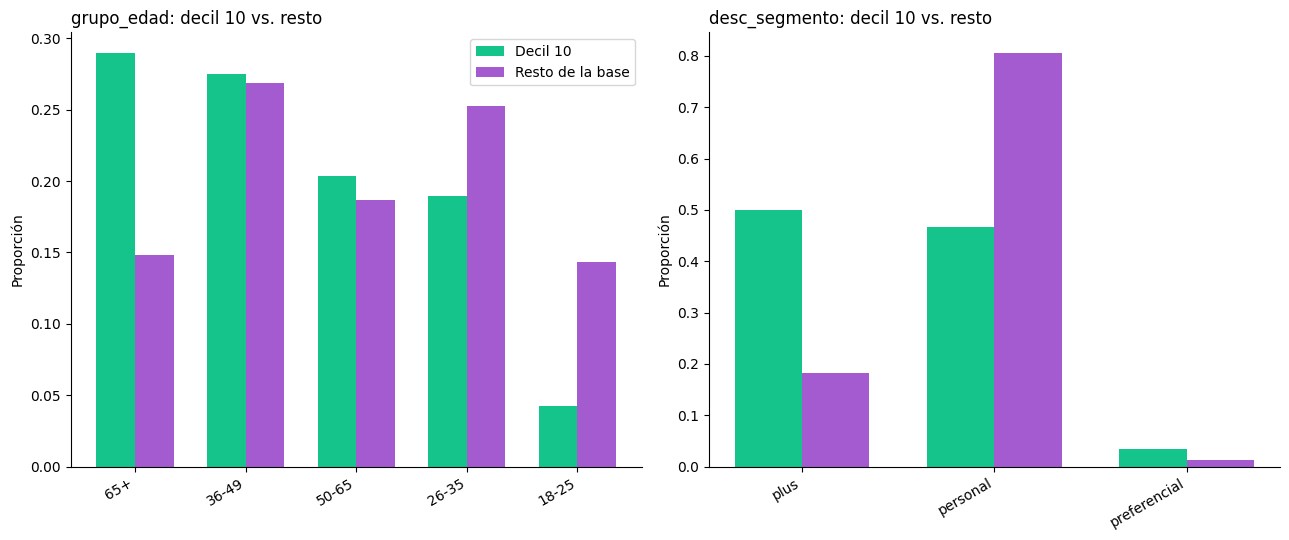

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, col in zip(axes, ["grupo_edad", "desc_segmento"]):
    tabla = pd.concat([
        decil_top[col].value_counts(normalize=True).rename("Decil 10"),
        resto[col].value_counts(normalize=True).rename("Resto de la base"),
    ], axis=1).fillna(0)
    tabla = tabla.reindex(tabla["Decil 10"].sort_values(ascending=False).index)
    x = np.arange(len(tabla))
    ancho = 0.35
    ax.bar(x - ancho/2, tabla["Decil 10"], width=ancho, label="Decil 10", color=PRINCIPAL)
    ax.bar(x + ancho/2, tabla["Resto de la base"], width=ancho, label="Resto de la base", color=PALETA['violeta'])
    ax.set_xticks(x); ax.set_xticklabels(tabla.index, rotation=30, ha="right")
    ax.set_ylabel("Proporción")
    ax.set_title(f"{col}: decil 10 vs. resto", fontsize=12, loc="left")
    ax.spines[["top", "right"]].set_visible(False)

axes[0].legend()
plt.tight_layout(); plt.show()

El decil 10 está claramente sesgado hacia clientes mayores y del segmento plus. Los clientes de 65+ pesan casi el doble en el decil 10 que en el resto de la base (29% vs. 15%), mientras que los de 18-25 años pesan solo un tercio de lo que pesan en el resto (4% vs. 14%) — el modelo prácticamente no está priorizando gente joven. Por segmento, el patrón es todavía más marcado: "plus" representa el 50% del decil 10 pero solo el 17.5% del resto de la base (casi 3 veces más peso relativo), mientras que "personal" —que es el segmento mayoritario del banco— cae de 79.5% en el resto a 45.5% en el decil 10. En corto: el grupo que el modelo identifica como más propenso a adoptar no se parece a la base general de clientes, se parece más a un cliente plus y de mayor edad. Vale la pena declarar esto como hallazgo explícito (igual que con el sesgo de censura): aunque grupo_edad y desc_segmento nunca entraron como variables del modelo, el patrimonio/ingreso/comportamiento financiero que sí usa terminan correlacionando fuertemente con esas dos características.

In [37]:
X_con_corte_log = np.log1p(X_con_corte.clip(lower=0))
escalador_sim = StandardScaler().fit(X_con_corte_log)
X_esc = escalador_sim.transform(X_con_corte_log)

centroide = X_esc[y_con_corte.values == 1].mean(axis=0)
df_con_corte["score_similitud"] = 1 / (1 + np.linalg.norm(X_esc - centroide, axis=1))
df_con_corte["score_modelo"] = modelo_final_prop.predict_proba(X_con_corte)[:, 1]

correlacion = np.corrcoef(df_con_corte["score_similitud"], df_con_corte["score_modelo"])[0, 1]
print(f"Correlación pooled: {correlacion:.3f}")

Correlación pooled: 0.490


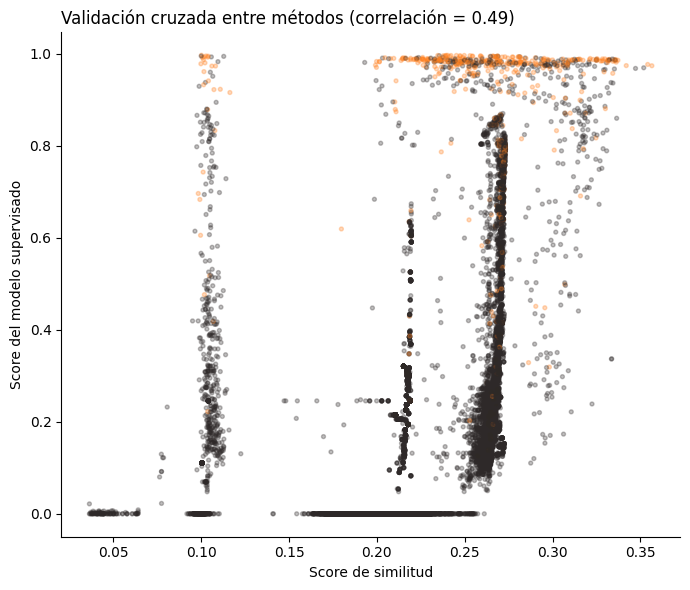

In [38]:
fig, ax = plt.subplots(figsize=(7, 6))
muestra = df_con_corte.sample(min(20000, len(df_con_corte)), random_state=42)
ax.scatter(muestra["score_similitud"], muestra["score_modelo"],
           c=muestra["proxy_adopcion"].map({0: ATENUADO, 1: ALERTA}), alpha=0.3, s=8)
ax.set_xlabel("Score de similitud"); ax.set_ylabel("Score del modelo supervisado")
ax.set_title(f"Validación cruzada entre métodos (correlación = {correlacion:.2f})", fontsize=12, loc="left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

 Los puntos naranjas (adoptantes) se agrupan casi todos cerca de la parte de arriba (score del modelo supervisado cerca de 1), pero repartidos en un rango amplio del eje horizontal (de 0.08 a 0.36 de score de similitud) — es decir, el modelo supervisado los califica a casi todos como "muy probables" con bastante seguridad, sin importar qué tan "parecidos" los considere el método de similitud. Ahí no hay mucho que correlacionar, porque un método varía poco (casi siempre da confianza alta) mientras el otro sí varía. En cambio, los puntos negros/grises (no adoptantes) se reparten en franjas verticales — grupos de clientes con features casi idénticas, lo cual genera esas columnas en vez de una nube continua — y dentro de esas franjas sí se nota una tendencia más clara: a mayor score de similitud, mayor también el score del modelo. Esa relación más ordenada entre los no-adoptantes es la que realmente sostiene el 0.49 pooled.

In [39]:
# diagnóstico por subgrupo (la correlación pooled está dominada por el subgrupo mayoritario
# -no-adoptantes-, no por una inversión de signo entre subgrupos)
flags = df_abt_crean[["numero_id", "tiene_invesbot", "tiene_inv_virtual"]]
df_valid = df_con_corte.merge(flags, on="numero_id", how="left")
for grupo, cond in [
    ("Solo invesbot", (df_valid["tiene_invesbot"] == 1) & (df_valid["tiene_inv_virtual"] == 0)),
    ("Solo inv_virtual", (df_valid["tiene_invesbot"] == 0) & (df_valid["tiene_inv_virtual"] == 1)),
    ("Ambos", (df_valid["tiene_invesbot"] == 1) & (df_valid["tiene_inv_virtual"] == 1)),
    ("No adoptantes", df_valid["proxy_adopcion"] == 0),
]:
    sub = df_valid[cond]
    if len(sub) > 5:
        corr = np.corrcoef(sub["score_similitud"], sub["score_modelo"])[0, 1]
        print(f"{grupo}: n={len(sub):,}, correlación={corr:.3f}")


Solo invesbot: n=1,604, correlación=0.122
Solo inv_virtual: n=18,360, correlación=0.116
Ambos: n=380, correlación=0.087
No adoptantes: n=795,975, correlación=0.491


El score de similitud (sin depender del proxy binario) muestra una correlación pooled de 0.494 con el modelo supervisado. Esta relación está dominada casi por completo por el grupo de no-adoptantes (0.494, n=795,975 — el 97.5% de la base): al ser la enorme mayoría de los datos, su comportamiento es prácticamente el mismo que el número pooled.

Dentro de los adoptantes confirmados, la correlación cae bastante (0.121 solo invesbot, 0.118 solo inv_virtual, 0.086 ambos) — sigue siendo positiva, pero mucho más débil. Esto es consistente con lo que muestra el gráfico: el modelo supervisado califica a casi todos los adoptantes con probabilidad alta y consistente, mientras que el score de similitud varía más entre ellos, así que hay menos margen para que ambos métodos coincidan en el orden fino dentro de ese grupo.

Para el uso práctico (priorizar clientes que aún no tienen el producto, que son el 97.5% de la base), la validación es sólida: ahí es donde los dos métodos sí concuerdan.

## Persistencia del modelo y exportación del score de propensión

Para que el notebook de monto potencial (parte 3) pueda combinar propensión × monto en un valor esperado de negocio, el score de cada cliente necesita quedar en un artefacto que otro notebook pueda leer directamente.

In [40]:
RUTA_MODELO_PROP = "/content/drive/MyDrive/data/modelo_propension_adopcion.joblib"
joblib.dump(modelo_final_prop, RUTA_MODELO_PROP)
print(f"Modelo persistido en {RUTA_MODELO_PROP}")

Modelo persistido en /content/drive/MyDrive/data/modelo_propension_adopcion.joblib


In [41]:
clientes_prospecto = df_abt_crean[df_abt_crean["proxy_adopcion"] == 0].copy()

X_score_prop = clientes_prospecto[["numero_id"] + cols_continuas +
                                   ["tiene_ahorro", "tiene_corriente", "tiene_bolsillos", "tiene_fiducuenta", "tiene_cdt"]].copy()
X_score_prop.columns = ["numero_id"] + cols_continuas + cols_binarias

clientes_prospecto["proba_adopcion"] = modelo_final_prop.predict_proba(X_score_prop[cols_modelo])[:, 1]

RUTA_SCORES_PROP = "/content/drive/MyDrive/data/scores_propension_adopcion.csv"
clientes_prospecto[["numero_id", "proba_adopcion"]].to_csv(RUTA_SCORES_PROP, index=False)

print(f"Scores exportados: {len(clientes_prospecto):,} clientes -> {RUTA_SCORES_PROP}")
print(clientes_prospecto["proba_adopcion"].describe())

Scores exportados: 795,975 clientes -> /content/drive/MyDrive/data/scores_propension_adopcion.csv
count    795975.000000
mean          0.155192
std           0.223186
min           0.000011
25%           0.000021
50%           0.000022
75%           0.237111
max           0.996866
Name: proba_adopcion, dtype: float64


## Resumen de supuestos del modelo de propensión

Antes de usar este modelo para priorización comercial, estos son los supuestos que lo sostienen:

1. **Proxy de adopción** = invesbot ∪ inversión virtual (no CDT, no bolsillos/fiducuenta): asume que estos dos productos digitales son análogos razonables de la nueva app.
2. **Umbral de 3 meses de historia previa**: mismo criterio que `confianza_historia` en el resto del ABT; excluye al 59.9% de los adoptantes reales (los que adoptaron muy temprano en la ventana observada).
3. **Asimetría precorte/contemporáneo**: correcta y necesaria para evitar fuga en los saldos de producto; limitación aceptada en `total_patrimonio_wz`/`ingresos_mensuales_wz` por falta de panel histórico para esas variables.
4. **Winsorización**: el tope p99 replica el mismo criterio ya usado en la capa bronze (holders únicamente).
5. **`class_weight="balanced"` + evaluación por PR-AUC/lift, no por accuracy/umbral 0.5**: dado un desbalance de ~2.5%, cualquier lectura de accuracy es engañosa; el negocio debe consumir el score continuo y priorizar por decil, no aplicar un corte binario.
6. **Sin variables demográficas** (`grupo_edad`, `desc_genero`, `desc_segmento`, `desc_tipo_de_vivienda`): aquì fueron excluidas deliberadamente para que la priorización comercial no dependa de edad o género.
7. **Ventana de datos de ~13 meses** (jun-2025 a jun-2026): el horizonte de negocio pedido es de 12 meses — la ventana observada apenas alcanza para cubrir un ciclo completo de adopción, y no permite validar si el patrón se mantiene estable año a año.

## Conclusiones generales del estudio

**El modelo sí distingue, de forma confiable, a los clientes con mayor probabilidad de adoptar la nueva aplicación de inversión.** Esta capacidad de predicción no fue casualidad ni depende de qué clientes en particular se usaron para probarla: se verificó comparando el modelo contra datos que nunca había visto, y repitiendo la prueba miles de veces con distintas combinaciones de esos mismos datos. En ambos casos el resultado se mantuvo estable. En términos simples, el modelo identifica a los clientes con mayor interés potencial hasta cerca de 8.7 veces mejor que si se eligiera al azar, en el 10% de clientes con el score más alto.

**La oportunidad de negocio no está repartida por igual entre todos los clientes: está concentrada en un grupo relativamente pequeño.** Más de la mitad de los clientes que aún no tienen el producto muestran, según el modelo, una probabilidad prácticamente nula de adoptarlo pronto. La verdadera oportunidad se concentra en apenas el 10% superior de la base, donde vive la gran mayoría del potencial real de conversión. Esto sugiere que una estrategia comercial enfocada en ese grupo específico sería mucho más efectiva que una campaña general dirigida a toda la base de clientes.

**Lo que más influye en la probabilidad de adoptar el producto no es cuánto dinero tiene el cliente, sino qué tan activa es su relación con el banco.** Los clientes que ya cuentan con una cuenta de ahorros activa, y que además manejan su dinero en productos más estructurados —como bolsillos o fiducuenta—, muestran una probabilidad mucho mayor de dar el siguiente paso hacia la inversión. Sorprendentemente, el patrimonio total del cliente casi no influye en el resultado. Este es un hallazgo importante: el cliente ideal para esta campaña no es necesariamente "el más rico", sino el que ya usa el banco de forma más activa y organizada.

**El grupo de clientes que el modelo identifica como prioritario tiene un perfil particular: tiende a ser de mayor edad y del segmento "plus", con menor presencia de clientes jóvenes o del segmento "personal".** Aunque el modelo nunca usó la edad ni el segmento del cliente como criterio de decisión, el resultado terminó reflejando ese patrón de todas formas, a través del comportamiento financiero. Esto no significa que el modelo esté mal construido, pero sí es información relevante para el equipo comercial: si la estrategia de la app busca también atraer clientes jóvenes o del segmento personal, este modelo, tal como está hoy, no los va a priorizar de forma natural.

**Existe una limitación conocida y documentada en el proceso.** El modelo solo pudo aprender del comportamiento de una parte de los clientes que ya adoptaron productos similares en el pasado: específicamente, de aquellos de quienes se tenía suficiente información previa a su adopción. La mayoría de los adoptantes reales no cumplía con ese requisito, principalmente porque adoptaron muy pronto después de que el banco empezara a registrar este tipo de comportamiento. Esta limitación se identificó, se midió y se dejó documentada de forma transparente, en lugar de pasarla por alto.

**Se comprobó, de forma intencional, que hacer las cosas correctamente no salió costoso en términos de resultados.** En un punto del análisis se comparó qué pasaría si al modelo se le diera información que en la vida real nunca tendría disponible (el comportamiento del cliente después de haber adoptado el producto, en lugar de antes) frente a hacerlo de la forma correcta y honesta. El resultado fue que el enfoque correcto no solo es más confiable, sino que además dio mejores resultados — no hubo que sacrificar calidad por hacer las cosas bien.

**El resultado final de este estudio es un listado con una probabilidad de adopción para cada uno de los cerca de 796 mil clientes que todavía no tienen el producto.** No incluye a quienes ya lo tienen, porque no tendría sentido dirigirles una campaña de algo que ya poseen. La recomendación de uso no es aplicar un punto de corte fijo (por ejemplo, "contactar a todo el que supere el 50% de probabilidad"), sino ordenar a los clientes de mayor a menor probabilidad y priorizar el contacto comercial empezando desde arriba, concentrando el esfuerzo donde realmente está la oportunidad.